In [1]:
import numpy as np
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags
from scipy.sparse import csr_matrix
from scipy import linalg as LA
from scipy.integrate import quad
import matplotlib.pyplot as plt
from scipy.sparse import diags

In [2]:
def u0(x):
    return np.exp(-10*(x-2)**2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


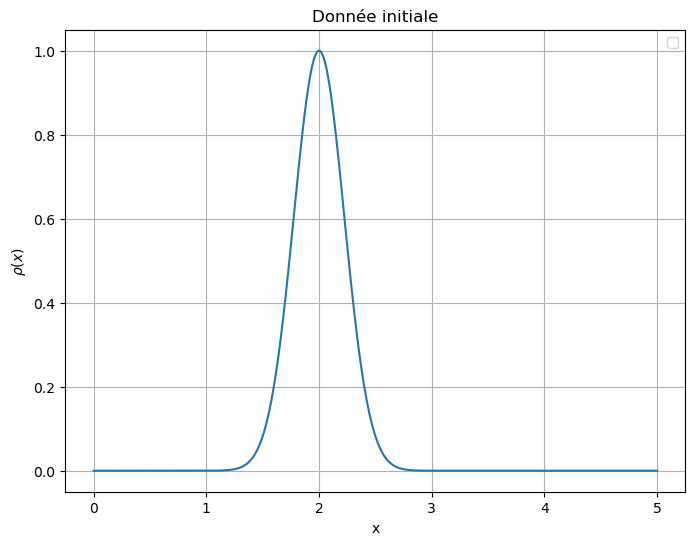

In [3]:
x_point = np.linspace(0, 5, 1000)
plt.figure(figsize=(8, 6))
plt.plot(x_point, u0(x_point))
plt.title('Donnée initiale')
plt.xlabel('x')
plt.ylabel(r'$\rho(x)$')
plt.legend()
plt.grid()
plt.savefig("Donnee initiale Burgers")
plt.show()

In [4]:
def burgers_upwind(x, u0, T, dt_init):
    """
    Résout l'équation de Burgers avec le schéma upwind.

    Paramètres:
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
"""
    N = len(x)-1 # Nombre de cellules
    u = u0[:-1].copy()
    dx = np.diff(x) # Pas d'espace


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations
    while t<T:

        # Calcul du pas de temps adaptatif (condition CFL)
        dt = min(dt_init, 0.9*np.min(dx)/np.max(np.abs(u)))

        #calcul des flux
        flux = np.zeros(N+1)
        for i in range(N+1):
            u_gauche = u[i-1] if i>0 else u[-1]         # cdt périodique

            u_droite = u[i] if i<N else u[0]

            if u_gauche + u_droite >= 0:
                flux[i] = 0.5*(u_gauche**2)
            else:
                flux[i] = 0.5*(u_droite**2 )

                
        #mise à jour
        u_new = u - (dt/dx)*(flux[1:]-flux[:-1])
        
    
        u = u_new
        t+=dt
        k+=1

        if t+dt> T:
            dt = T-t

    print("Upwind, itérations : ", k)

    return u


Upwind, itérations :  109
Upwind, itérations :  214
Upwind, itérations :  319
Upwind, itérations :  424
Upwind, itérations :  529


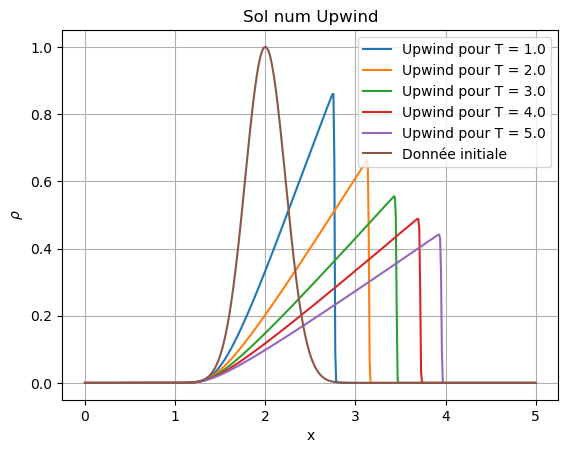

In [5]:
x = np.linspace(0, 5, 500)
u_0 = u0(x)
T_values = [1., 2., 3., 4., 5.]
for T in T_values:
    dt = 0.95*(x[1]-x[0])
    u1 = burgers_upwind(x, u_0, T, dt)
    plt.plot(x[:-1], u1, label = f"Upwind pour T = {T}")

plt.plot(x, u_0, label = "Donnée initiale")
plt.xlabel('x')
plt.ylabel(r"$\rho$")
plt.title('Sol num Upwind')
plt.grid()
plt.legend()
plt.savefig("Sol Burgers upwind.png")
plt.show()


In [6]:
x = np.linspace(0, 5, 1000)
u_0= u0(x)
result, _ = quad(u0, 0, 5)#je calcule l'integrale de la donnée initiale sur [0, 5] (juste par curiosité)
print(f"L'intégrale de u_init sur [0, 5] est : {result}")

dt = 0.95*(x[1]-x[0])
u1= burgers_upwind(x, u_0, T, dt)
integ = np.trapz(u1, x[:-1])
print(f"L'intégrale de la solution numérique du schéma Upwind (trapèzes) est : {integ}") #on a bien la préservation de la masse pour Upwind aussi

L'intégrale de u_init sur [0, 5] est : 0.5604991216397928
Upwind, itérations :  1060
L'intégrale de la solution numérique du schéma Upwind (trapèzes) est : 0.5604991216397927


In [7]:
def burgers_upwind_non_conservatif(x, u0, T, dt_init):
    """
    Résout l'équation de Burgers avec le schéma upwind non conservatif.

    Paramètres:
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
"""
    N = len(x)-1
    u = u0[:-1].copy()
    dx = np.diff(x)
    

    t= 0
    k=0
    while t<T:
        dt = min(dt_init, 0.9*np.min(dx)/np.max(np.abs(u)))
        #calcul des flux
        flux = np.zeros(N+1)
        for i in range(N+1):
            u_gauche = u[i-1] if i>0 else u[-1] #cdt périodique
            u_droite = u[i] if i<N else u[0] #cdt périodique

            flux[i] = (u_droite - u_gauche)*(u_gauche - np.abs(u_gauche))/2

        #mise à jour
        u_new = u-(dt/dx)*(flux[1:]-flux[:-1])
        
        # cdt périodique
        u = u_new
        t+=dt
        k+=1

        if t+dt>T:
            dt = T-t

    print("Upwind non conservatif, itérations : ", k)

    return u


Upwind non conservatif, itérations :  111


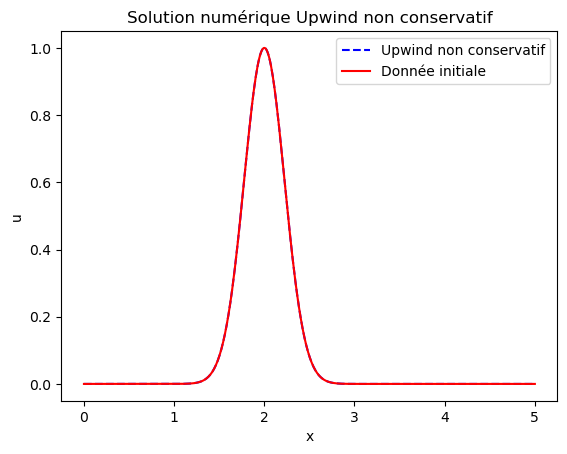

In [8]:
x = np.linspace(0, 5, 500)
u_0 = u0(x)
T = 1.
dt = 0.95*(x[1]-x[0])
u1 = burgers_upwind_non_conservatif(x, u_0, T, dt)
plt.plot(x[:-1], u1, 'b--', label='Upwind non conservatif')
plt.plot(x, u_0, 'r-', label='Donnée initiale')
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution numérique Upwind non conservatif')
plt.legend()
plt.show()

In [9]:
x = np.linspace(0, 5, 1000)
u_0= u0(x)
result, _ = quad(u0, 0, 5)#je calcule l'integrale de la donnée initiale sur [0, 5] (juste par curiosité)
print(f"L'intégrale de u_init sur [0, 5] est : {result}")

dt = 0.95*(x[1]-x[0])
u1= burgers_upwind_non_conservatif(x, u_0, T, dt)
integ = np.trapz(u1, x[:-1])
print(f"L'intégrale de la solution numérique du schéma Upwind non conservatif (trapèzes) est : {integ}") #on a bien la préservation de la masse pour Upwind non conservatif aussi

L'intégrale de u_init sur [0, 5] est : 0.5604991216397928
Upwind non conservatif, itérations :  222
L'intégrale de la solution numérique du schéma Upwind non conservatif (trapèzes) est : 0.5604991216397929


Upwind non conservatif, itérations :  111
Upwind non conservatif, itérations :  222
Upwind non conservatif, itérations :  333
Upwind non conservatif, itérations :  444
Upwind non conservatif, itérations :  555


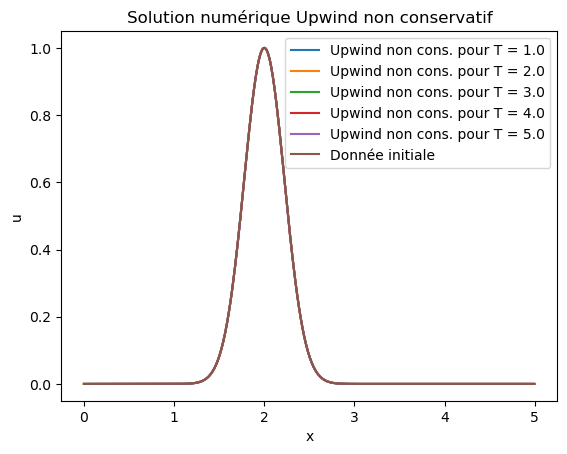

In [10]:
x = np.linspace(0, 5, 500)
u_0 = u0(x)
T_values = [1., 2., 3., 4., 5.]
for T in T_values:
    dt = 0.95*(x[1]-x[0])
    u1 = burgers_upwind_non_conservatif(x, u_0, T, dt)
    plt.plot(x[:-1], u1, label = f"Upwind non cons. pour T = {T}")

plt.plot(x, u_0, label = "Donnée initiale")
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution numérique Upwind non conservatif')
plt.legend()
plt.show()


Upwind non conservatif, itérations :  222


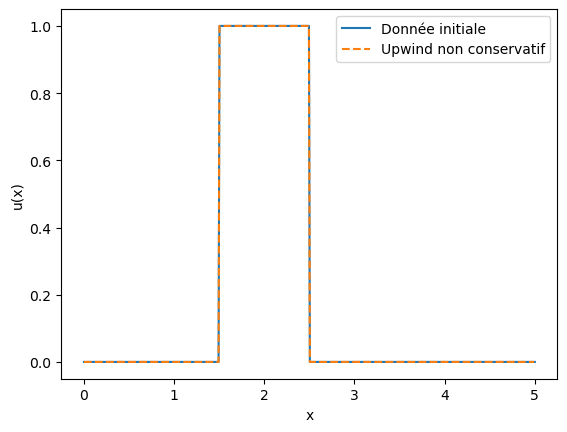

In [11]:
def u01(x):
    return np.where((x >= 1.5) & (x <= 2.5), 1, 0)

x = np.linspace(0, 5, 500)
u_01 = u01(x)
T =2.
dt = 0.95*(x[1]-x[0])
u1 = burgers_upwind_non_conservatif(x, u_01, T, dt)
plt.plot(x, u_01, label = "Donnée initiale")
plt.plot(x[:-1], u1, '--', label='Upwind non conservatif')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.show()

In [12]:
x = np.linspace(0, 5, 1000)
u_01= u01(x)
result, _ = quad(u01, 0, 5)#je calcule l'integrale de la donnée initiale sur [0, 5] (juste par curiosité)
print(f"L'intégrale de u_init sur [0, 5] est : {result}")

dt = 0.95*(x[1]-x[0])
u1= burgers_upwind_non_conservatif(x, u_01, T, dt)
integ = np.trapz(u1, x[:-1])
print(f"L'intégrale de la solution numérique du schéma Upwind non conservatif (trapèzes) est : {integ}") #on a bien la préservation de la masse pour Upwind non conservatif aussi

L'intégrale de u_init sur [0, 5] est : 0.9999999999999998
Upwind non conservatif, itérations :  445
L'intégrale de la solution numérique du schéma Upwind non conservatif (trapèzes) est : 1.001001001001001


In [13]:
def burgers_roe(x, u0, T, dt_init):
    """
    Résout l'équation de Burgers avec le schéma Roe.

    Paramètres:
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
"""
    N = len(x)-1
    u = u0[:-1].copy()
    dx = np.diff(x)


    t= 0
    k=0
    while t<T:
        u_new = u.copy()
        dt = min(dt_init, 0.9*np.min(dx)/np.max(np.abs(u)))

        #calcul des flux
        flux = np.zeros(N+1)
        for i in range(N+1):
            u_gauche = u[i-1] if i>0 else u[-1]    # cdt périodique

            u_droite = u[i] if i<N else u[0]

            if u_gauche + u_droite >= 0: # j'ai simplifié l'écriture des conditions pour les calcul du flux de Roe (qui est un peu similaire au schéma Upwind pour l'equation de Burgers)
                flux[i] = 0.5*(u_gauche**2)
            else:
                flux[i] = 0.5*(u_droite**2 )

                

      #mise à jour
        u_new = u - (dt/dx)*(flux[1:]-flux[:-1])
    
        u = u_new
        t+=dt
        k+=1

        if t+dt> T:
            dt = T-t
    print("Roe, itérations : ", k)

    return u


Roe, itérations :  109
Roe, itérations :  214
Roe, itérations :  319
Roe, itérations :  424
Roe, itérations :  529


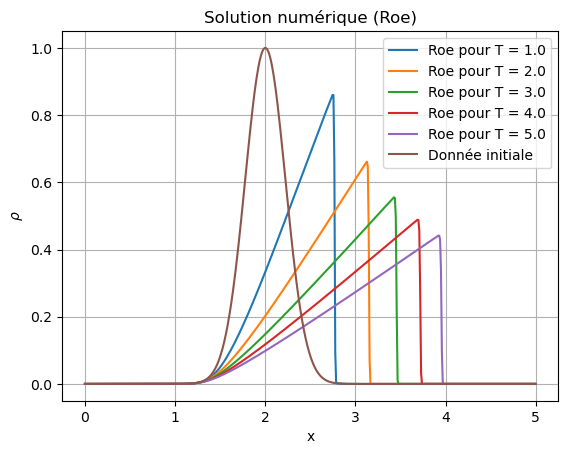

In [14]:
x = np.linspace(0, 5, 500)
u_0 = u0(x)
T_values = [1., 2., 3., 4., 5.]
for T in T_values:
    dt = 0.95*(x[1]-x[0])
    u1 = burgers_roe(x, u_0, T, dt)
    plt.plot(x[:-1], u1, label = f"Roe pour T = {T}")

plt.plot(x, u_0, label = "Donnée initiale")
plt.xlabel('x')
plt.ylabel(r"$\rho$")
plt.title('Solution numérique (Roe)')
plt.legend()
plt.grid()
plt.savefig("Sol Burgers roe.png")
plt.show()


Roe, itérations :  111
Roe, itérations :  222


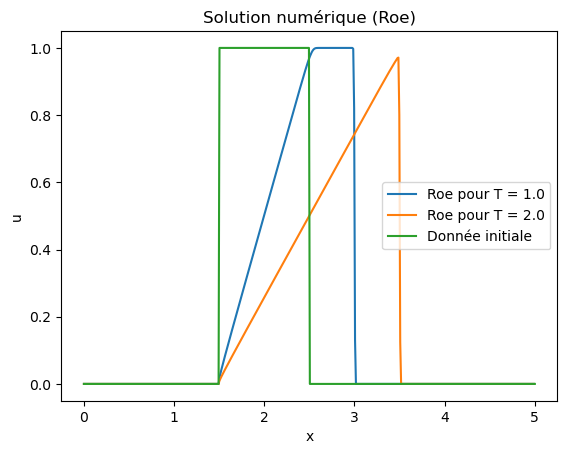

In [15]:
x = np.linspace(0, 5, 500)
u_01 = u01(x)
T_values = [1., 2.]
for T in T_values:
    dt = 0.95*(x[1]-x[0])
    u1 = burgers_roe(x, u_01, T, dt)
    plt.plot(x[:-1], u1, label = f"Roe pour T = {T}")

plt.plot(x, u_01, label = "Donnée initiale")
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution numérique (Roe)')
plt.legend()
plt.show()


In [16]:
def burgers_lf(x, u0, T, dt): #schéma de Lax-friedrichs
    """
    Résout l'équation de Burgers avec le schéma de Lax-friedrichs.

    Paramètres:
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
"""
    N = len(x)-1
    u = u0[:-1].copy()
    dx = np.diff(x)

    t= 0
    k = 0
    while t<T:
        dt = min(dt, 0.9*np.min(dx)/np.max(np.abs(u)))

        #calcul des flux
        flux = np.zeros(N+1)
        u_gauche = np.zeros(N+1)
        u_droite = np.zeros(N+1)

        for i in range(N+1):
            u_gauche[i] = u[i-1] if i>0 else u[-1]    # cdt périodique
            u_droite[i] = u[i] if i<N else u[0]

        flux[:-1]= 0.25*(u_gauche[:-1]**2 + u_droite[:-1]**2) - 0.5*(dx/dt)*(u_droite[:-1]-u_gauche[:-1])
        flux[-1] = flux[0] #cdt périodique

      #mise à jour
        u_new = u - (dt/dx)*(flux[1:]-flux[:-1])
    
        t+=dt
        k +=1 
        u = u_new

        if t+dt> T:
            dt = T-t
        
    print("Lax-Friedrichs, itérations : ", k)
    return u


Lax-Friedrichs, itérations :  111
Lax-Friedrichs, itérations :  222
Lax-Friedrichs, itérations :  333
Lax-Friedrichs, itérations :  444
Lax-Friedrichs, itérations :  555


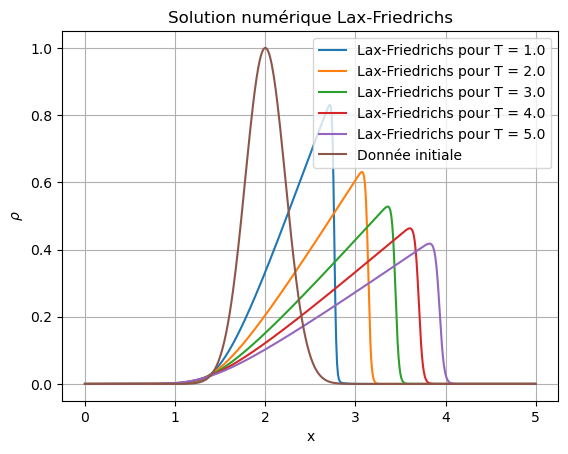

In [17]:
x = np.linspace(0, 5, 500)
u_0 = u0(x)
T_values = [1., 2., 3., 4., 5.]
for T in T_values:
    dt = 0.95*(x[1]-x[0])
    u1 = burgers_lf(x, u_0, T, dt)
    plt.plot(x[:-1], u1, label = f"Lax-Friedrichs pour T = {T}")

plt.plot(x, u_0, label = "Donnée initiale")
plt.xlabel('x')
plt.ylabel(r"$\rho$")
plt.title('Solution numérique Lax-Friedrichs')
plt.legend()
plt.grid()
plt.savefig("sol burgers LF.png")
plt.show()


Lax-Friedrichs, itérations :  223
Lax-Friedrichs, itérations :  445
Lax-Friedrichs, itérations :  666


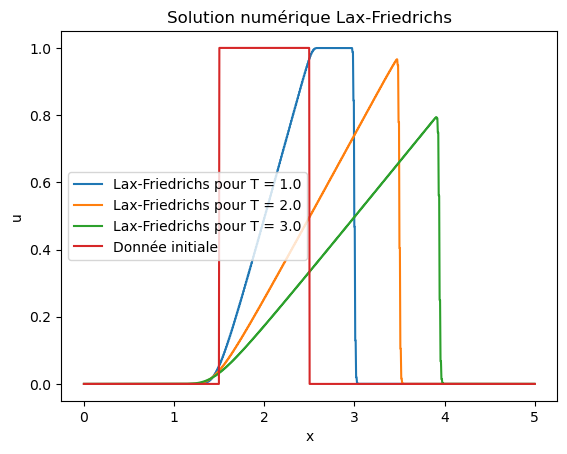

In [18]:
x = np.linspace(0, 5, 1000)
u_01 = u01(x)
T_values = [1., 2., 3.]
for T in T_values:
    dt = 0.95*(x[1]-x[0])
    u1 = burgers_lf(x, u_01, T, dt)
    plt.plot(x[:-1], u1, label = f"Lax-Friedrichs pour T = {T}")

plt.plot(x, u_01, label = "Donnée initiale")
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution numérique Lax-Friedrichs')
plt.legend()
plt.show()


In [19]:
def burgers_lw(x, u0, T, dt_init): #schéma de Lax-Wendroff
    """
    Résout l'équation de Burgers avec le schéma de Lax-Wendroff.

    Paramètres:
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
"""
    N = len(x)-1
    u = u0[:-1].copy()
    dx = np.diff(x)

    t= 0
    k = 0
    while t<T:
        dt = min(dt_init, 0.4*np.min(dx)/np.max(np.abs(u)))
       # cfl = np.max(np.abs(u))*dt/np.min(dx)
        
        #calcul des flux
        flux = np.zeros(N+1)
        u_gauche = np.zeros(N+1)
        u_droite = np.zeros(N+1)

        for i in range(N+1):
            u_gauche[i] = u[i-1] if i>0 else u[-1]    # cdt périodique
            u_droite[i] = u[i] if i<N else u[0]

        flux[:-1]= 0.25*(u_gauche[:-1]**2 + u_droite[:-1]**2) - 0.25*(dt/dx)*(u_droite[:-1]+u_gauche[:-1])*(u_droite[:-1]**2-u_gauche[:-1]**2)/2
        flux[-1] = flux[0] #cdt périodique
    
          #mise à jour
        u_new = u - (dt/dx)*(flux[1:]-flux[:-1])

        
        t+=dt
        u = u_new
        k+=1

        if t+dt>T:
            dt = T-t

        
    print("Lax-Wendroff, itérations : ", k)

    return u


Lax-Wendroff, itérations :  274
Lax-Wendroff, itérations :  507
Lax-Wendroff, itérations :  693


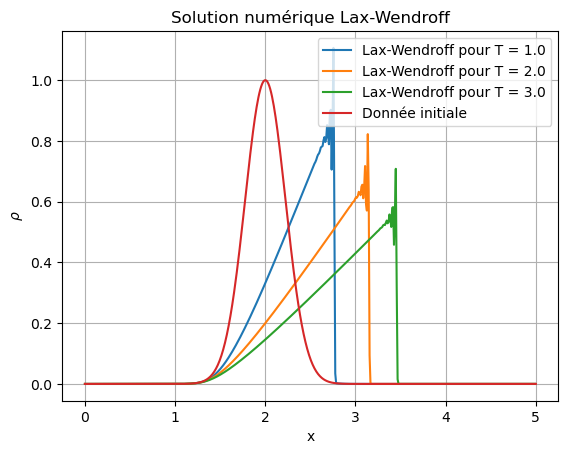

In [20]:
x = np.linspace(0, 5, 500)
u_0 = u0(x)
T_values = [1., 2., 3.]
for T in T_values:
    dt = 0.95*(x[1]-x[0])
    u1 = burgers_lw(x, u_0, T, dt)
    plt.plot(x[:-1], u1, label = f"Lax-Wendroff pour T = {T}")

plt.plot(x, u_0, label = "Donnée initiale")
plt.xlabel('x')
plt.ylabel(r"$\rho$")
plt.title('Solution numérique Lax-Wendroff')
plt.legend()
plt.grid()
plt.savefig("sol burgers LW.png")
plt.show()


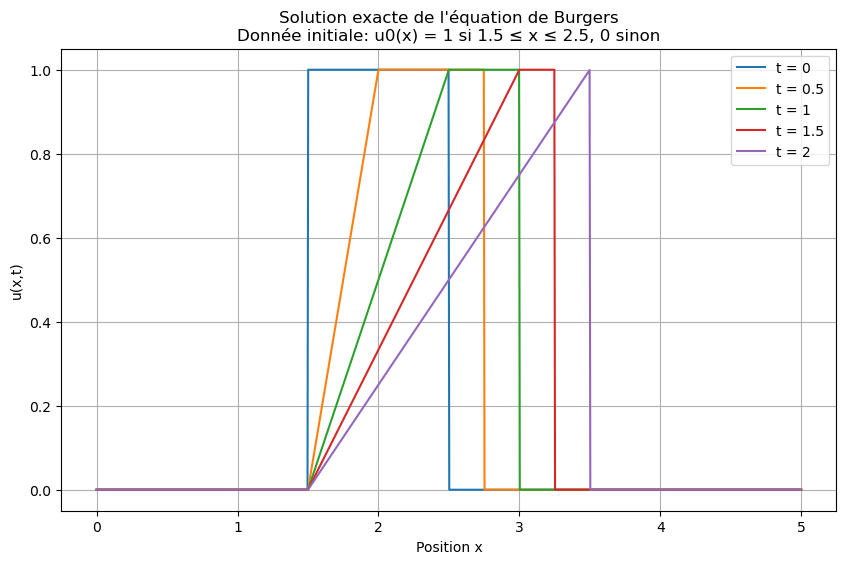

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def u_exact(x, t):
    """
    Solution exacte de l'équation de Burgers pour la donnée initiale :
    u0(x) = 1 si 1.5 <= x <= 2.5, 0 sinon.
    
    Paramètres:
        x : array_like, positions où évaluer la solution
        t : float, temps auquel calculer la solution
        
    Retourne:
        u : array, valeurs de la solution exacte aux positions x
    """
    u = np.zeros_like(x)
    
    # Position du choc (discontinuité à droite)
    shock_position = 2.5 + 0.5 * t
    
    # Position de la fin de la détente (onde de détente à gauche)
    fan_end = 1.5 + t
    
    # Conditions pour les différentes régions
    left_fan = (x >= 1.5) & (x <= fan_end)
    plateau = (x > fan_end) & (x < shock_position)
    
    # Calcul des valeurs
    u[left_fan] = (x[left_fan] - 1.5) / t
    u[plateau] = 1
    
    return u

# Paramètres pour la visualisation
x = np.linspace(0, 5, 1000)  # Domaine spatial
times = [0, 0.5, 1, 1.5, 2]   # Temps à visualiser

# Visualisation
plt.figure(figsize=(10, 6))
for t in times:
    plt.plot(x, u_exact(x, t), label=f't = {t}')
    
plt.title('Solution exacte de l\'équation de Burgers\n'
          'Donnée initiale: u0(x) = 1 si 1.5 ≤ x ≤ 2.5, 0 sinon')
plt.xlabel('Position x')
plt.ylabel('u(x,t)')
plt.legend()
plt.grid(True)
plt.show()

Lax-Wendroff, itérations :  381


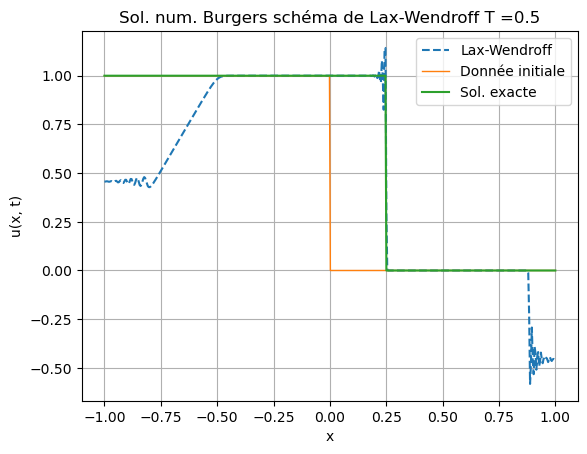

In [57]:
x = np.linspace(-1, 1, 500)
def u_init(x):
    return np.where(x>0, 0., 1.)
def u_exact0(x, t):
    return np.where(x/t < 0.5, 1., 0.)


u_01 = u_init(x)
T_values = [0.5]
for T in T_values:
    dt = 0.95*(x[1]-x[0])
    u1 = burgers_lw(x, u_01, T, dt)
    plt.plot(x[:-1], u1, '--',label = f"Lax-Wendroff")

plt.plot(x, u_01, linewidth = 1,label = "Donnée initiale")
plt.plot(x, u_exact0(x, 0.5), linewidth = 1.5, label = "Sol. exacte")

plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f'Sol. num. Burgers schéma de Lax-Wendroff T ={T}')
plt.legend()
plt.grid()
plt.savefig("sol pb reimann LW.png") #sauvegarde de la figur
plt.show()


Upwind, itérations :  56
Roe, itérations :  56
Lax-Friedrichs, itérations :  56
Lax-Wendroff, itérations :  130


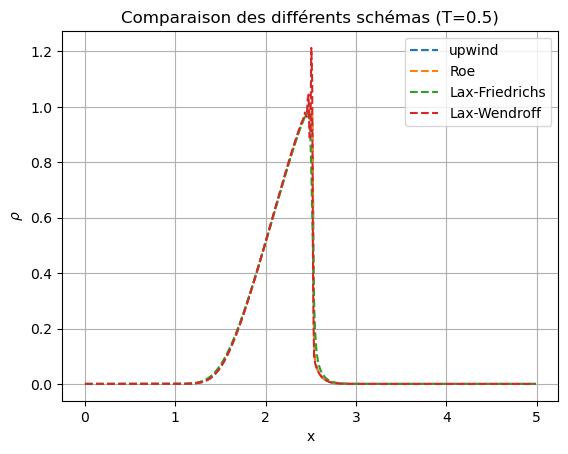

In [22]:
x = np.linspace(0, 5, 500)
u_0 = u0(x)
u_01 = u0(x)
u_02 = u0(x)
u_03 = u0(x)
T = 0.5
dt = 0.95*(x[1]-x[0])
u1 = burgers_upwind(x, u_0, T, dt)
w1 = burgers_roe(x, u_01, T, dt)
y1 = burgers_lf(x, u_02, T, dt)
z1 = burgers_lw(x, u_03, T, dt)
plt.plot(x[:-1], u1, '--', label = "upwind")
plt.plot(x[:-1], w1, '--', label = "Roe")
plt.plot(x[:-1], y1,'--', label = "Lax-Friedrichs")
plt.plot(x[:-1], z1, '--', label = "Lax-Wendroff")
plt.xlabel("x")
plt.ylabel(r"$\rho$")
plt.title("Comparaison des différents schémas (T=0.5)")
plt.legend()
plt.grid()
plt.savefig("compar sol burgers.png")
plt.show()

Upwind, itérations :  111
Upwind non conservatif, itérations :  111
Roe, itérations :  111
Lax-Friedrichs, itérations :  111
Lax-Wendroff, itérations :  305


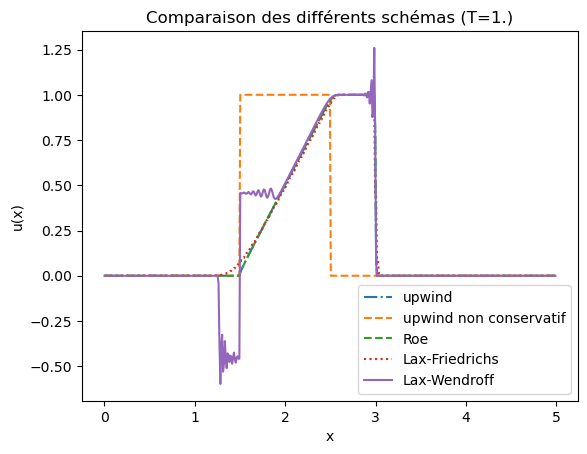

In [23]:
#Exemple avec la donnée initiale u01 (non dérivable)
x = np.linspace(0, 5, 500)
u_01 = u01(x)
T = 1.
dt = 0.95*(x[1]-x[0])
u11 = burgers_upwind(x, u_01, T, dt)
v11 = burgers_upwind_non_conservatif(x, u_01, T, dt)
w11 = burgers_roe(x, u_01, T, dt)
y11 = burgers_lf(x, u_01, T, dt)
z11 = burgers_lw(x, u_01, T, dt)
plt.plot(x[:-1], u11, '-.', label = "upwind")
plt.plot(x[:-1], v11, '--', label = "upwind non conservatif")
plt.plot(x[:-1], w11, '--', label = "Roe")
plt.plot(x[:-1], y11,':', label = "Lax-Friedrichs")
plt.plot(x[:-1], z11, '-', label = "Lax-Wendroff")
plt.xlabel("x")
plt.ylabel('u(x)')
plt.title("Comparaison des différents schémas (T=1.)")
plt.legend()
plt.show()

##### Ordre des schémas #####

In [24]:
# je prends u_exact = exp(-(x-t)**2), solution analytique (fabriquée)
def u_exact(x, t):
    return np.exp(-(x-t)**2)
def f(x, t):    
    return 2*(x-t)*np.exp(-(x-t)**2)*(1-np.exp(-(x-t)**2))

In [25]:
def burgers_upwind_f(f, x, u0, T, dt_init):
    """
    Résout l'équation de Burgers avec second membre avec le schéma upwind.

    Paramètres:
    f : second membre
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
    """
    N = len(x)-1 # Nombre de cellules
    u = u0[:-1].copy()
    dx = np.diff(x) # Pas d'espace


    t= 0 # Temps initial
    k=0 # pour compter le nombre d'itérations

    dtf = dt_init
    while t<T:

        # Calcul du pas de temps adaptatif (condition CFL)
        dt = min(dt_init, 0.9*np.min(dx)/np.max(np.abs(u)))

        #calcul des flux
        flux = np.zeros(N+1)
        for i in range(N+1):
            u_gauche = u[i-1] if i>0 else u[-1]         # cdt périodique

            u_droite = u[i] if i<N else u[0]

            if u_gauche + u_droite >= 0:
                flux[i] = 0.5*(u_gauche**2)
            else:
                flux[i] = 0.5*(u_droite**2 )

                
        #mise à jour
        u_new = u - (dt/dx)*(flux[1:]-flux[:-1])+ dt*f(x[:-1], t)
        
    
        u = u_new
        t+=dt
        k+=1

        if t+dt> T:
            dt = T-t

        dtf = dt

    print("Upwind, itérations : ", k)


    return u, dtf


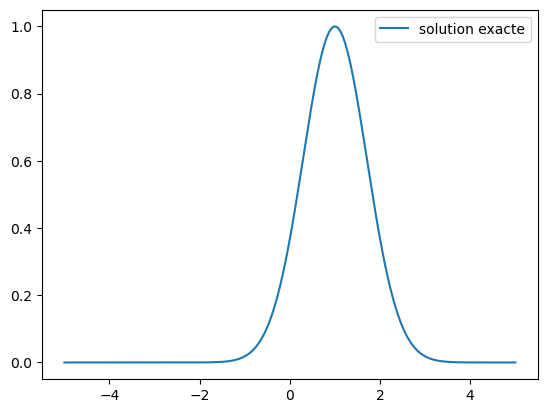

In [26]:
T = 1.
x = np.linspace(-5, 5, 1000)
plt.plot(x, u_exact(x, T), label = "solution exacte")
plt.legend()
plt.show()


Upwind, itérations :  1000
Upwind, itérations :  1000
Upwind, itérations :  1000
Upwind, itérations :  1000
Upwind, itérations :  1000
Upwind, itérations :  1000
[-6.661338147750939e-16, -6.661338147750939e-16, -6.661338147750939e-16, -6.661338147750939e-16, -6.661338147750939e-16, -6.661338147750939e-16]
Ordre de convergence Linf (Upwind) estimé: 0.98
Ordre de convergence L2 (Upwind) estimé: 0.52


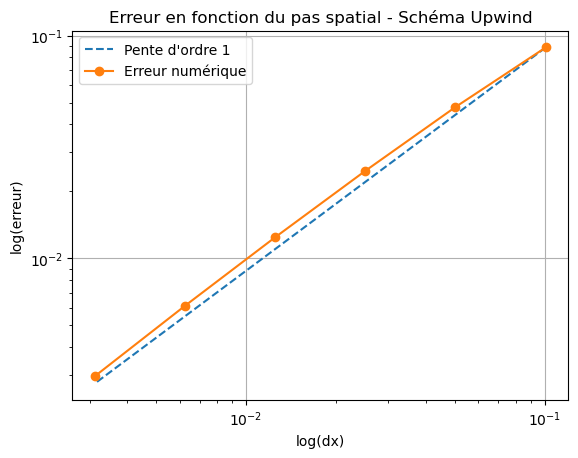

In [27]:
T= 1.
dt_init = 0.001
N_values = [100, 200,400, 800, 1600, 3200]
vals_erreurLinf = []
vals_erreurL2 = []
dx_vals = []

dtfs = []
for N in N_values:
    x = np.linspace(-5, 5, N)
    dx = np.diff(x)
    u0 = u_exact(x, 0) #condition initiale
    u, dtf = burgers_upwind_f(f, x, u0, T, dt_init)
    xm = (x[:-1]+x[1:])/2.
    u_e = u_exact(xm, T)
    dtfs.append(dtf)

    

    erreur = u - u_e
    vals_erreurLinf.append(np.max(np.abs(erreur)))
    vals_erreurL2.append(np.sqrt(np.sum(erreur**2)))
    dx_vals.append(np.mean(dx))


print(dtfs)
log_dx = np.log(dx_vals)
log_N= np.log(N_values)
log_erreurLinf = np.log(vals_erreurLinf)
log_erreurL2 = np.log(vals_erreurL2)

pente2, intercept2 = np.polyfit(log_dx, log_erreurLinf, 1)
pente3, intercept3 = np.polyfit(log_dx, log_erreurL2, 1)
print(f"Ordre de convergence Linf (Upwind) estimé: {pente2:.2f}")
print(f"Ordre de convergence L2 (Upwind) estimé: {pente3:.2f}")



# Ajout de la pente d'ordre 1
dx_ref = np.array(dx_vals)
erreur_ref = vals_erreurLinf[0] * (dx_ref / dx_ref[0])  # Droite de référence avec pente 1
plt.loglog(dx_ref, erreur_ref, linestyle='--', label="Pente d'ordre 1")

plt.loglog(dx_vals, vals_erreurLinf, marker='o', label="Erreur numérique")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial - Schéma Upwind')
plt.legend()
plt.grid()   
plt.savefig("erreur Linf burgers upwind.png") 
plt.show()

In [28]:
def burgers_lf_f(f,x, u0, T, dt): #schéma de Lax-friedrichs
    """
    Résout l'équation de Burgers avec second membre avec le schéma Lax-friedrichs.

    Paramètres:
    f : second membre
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
    """
    N = len(x)-1
    u = u0[:-1].copy()
    dx = np.diff(x)

    t= 0
    k = 0
    while t<T:
        dt = min(dt, 0.9*np.min(dx)/np.max(np.abs(u)))

        #calcul des flux
        flux = np.zeros(N+1)
        u_gauche = np.zeros(N+1)
        u_droite = np.zeros(N+1)

        for i in range(N+1):
            u_gauche[i] = u[i-1] if i>0 else u[-1]    # cdt périodique
            u_droite[i] = u[i] if i<N else u[0]

        flux[:-1]= 0.25*(u_gauche[:-1]**2 + u_droite[:-1]**2) - 0.5*(dx/dt)*(u_droite[:-1]-u_gauche[:-1])
        flux[-1] = flux[0] #cdt périodique

      #mise à jour
        u_new = u - (dt/dx)*(flux[1:]-flux[:-1]) + dt*f(x[:-1], t)
    
        t+=dt
        k +=1 
        u = u_new

        if t+dt> T:
            dt = T-t
        
    print("Lax-Friedrichs, itérations : ", k)
    return u


Lax-Friedrichs, itérations :  356
Lax-Friedrichs, itérations :  711
Lax-Friedrichs, itérations :  1423
Lax-Friedrichs, itérations :  2845
Ordre de convergence Linf (Lax Friedrichs) estimé: 1.00
Ordre de convergence L2 (Lax Friedrichs) estimé: 0.50


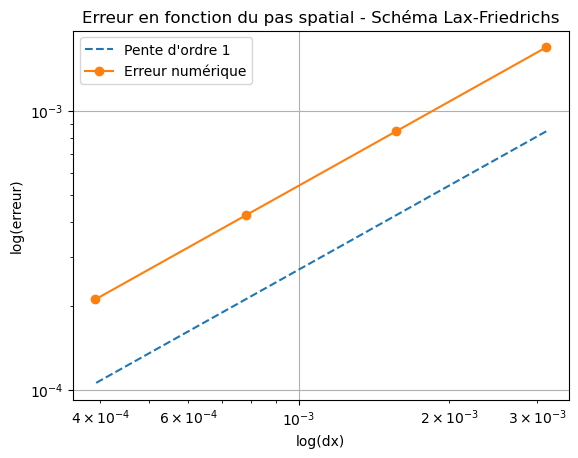

In [29]:
T= 1.
dt_init = 0.01
N_values = [3200, 6400, 12800, 25600]
vals_erreurLinf = []
vals_erreurL2 = []
dx_vals = []
for N in N_values:
    x = np.linspace(-5, 5, N)
    dx = np.diff(x)
    u0 = u_exact(x, 0) #condition initiale
    u = burgers_lf_f(f,x, u0, T, dt_init)
    xm = (x[:-1]+x[1:])/2.
    u_e = u_exact(xm, T)
    

    erreur = u - u_e
    vals_erreurLinf.append(np.max(np.abs(erreur)))
    vals_erreurL2.append(np.sqrt(np.sum(erreur**2)))
    dx_vals.append(np.mean(dx))


log_dx = np.log(dx_vals)
log_N= np.log(N_values)
log_erreurLinf = np.log(vals_erreurLinf)
log_erreurL2 = np.log(vals_erreurL2)
pente2, intercept2 = np.polyfit(log_dx, log_erreurLinf, 1)
pente3, intercept3 = np.polyfit(log_dx, log_erreurL2, 1)

print(f"Ordre de convergence Linf (Lax Friedrichs) estimé: {pente2:.2f}")
print(f"Ordre de convergence L2 (Lax Friedrichs) estimé: {pente3:.2f}")


# Ajout de la pente d'ordre 2
dx_ref = np.array(dx_vals)
erreur_ref = 0.5*vals_erreurLinf[0] * (dx_ref / dx_ref[0])  # Droite de référence avec pente 2
plt.loglog(dx_ref, erreur_ref, linestyle='--', label="Pente d'ordre 1")

plt.loglog(dx_vals, vals_erreurLinf, marker='o', label="Erreur numérique")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial - Schéma Lax-Friedrichs')
plt.legend()
plt.grid()
plt.savefig("erreur Linf burgers LF.png")   
plt.show()

In [30]:
def burgers_lw_f(f, x, u0, T, dt_init): #schéma de Lax-Wendroff
    """
    Résout l'équation de Burgers avec second membre avec le schéma Lax-Wendroff.

    Paramètres:
    f : second membre
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
    """
    N = len(x)-1
    u = u0[:-1].copy()
    dx = np.diff(x)

    t= 0
    k = 0
    while t<T:
        dt = min(dt_init, 0.4*np.min(dx)/np.max(np.abs(u)))
       # cfl = np.max(np.abs(u))*dt/np.min(dx)
        
        #calcul des flux
        flux = np.zeros(N+1)
        u_gauche = np.zeros(N+1)
        u_droite = np.zeros(N+1)

        for i in range(N+1):
            u_gauche[i] = u[i-1] if i>0 else u[-1]    # cdt périodique
            u_droite[i] = u[i] if i<N else u[0]

        flux[:-1]= 0.25*(u_gauche[:-1]**2 + u_droite[:-1]**2) - 0.25*(dt/dx)*(u_droite[:-1]+u_gauche[:-1])*(u_droite[:-1]**2-u_gauche[:-1]**2)/2
        flux[-1] = flux[0] #cdt périodique
    
          #mise à jour
        u_new = u - (dt/dx)*(flux[1:]-flux[:-1]) + dt*f(x[:-1], t)

        
        t+=dt
        u = u_new
        k+=1

        if t+dt>T:
            dt = T-t

        
    print("Lax-Wendroff, itérations : ", k)

    return u


Lax-Wendroff, itérations :  800
Lax-Wendroff, itérations :  1600
Lax-Wendroff, itérations :  3200
Lax-Wendroff, itérations :  6400
Ordre de convergence Linf (Lax-Wendroff) estimé: 1.00
Ordre de convergence L2 (Lax-Wendroff) estimé: 0.50


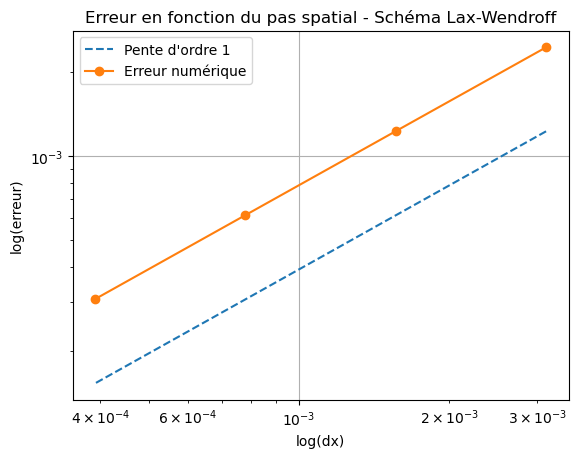

In [31]:
T= 1.
dt_init = 0.01
N_values = [3200, 6400, 12800, 25600]
vals_erreurLinf = []
vals_erreurL2 = []
dx_vals = []
for N in N_values:
    x = np.linspace(-5, 5, N)
    xm = (x[:-1]+x[1:])/2.
    dx = x[1]-x[0]
    u0 = u_exact(x, 0) #condition initiale
    u = burgers_lw_f(f,x, u0, T, dt_init)
    u_e = u_exact(xm, T) 

    erreur = u - u_e
    vals_erreurLinf.append(np.max(np.abs(erreur)))
    vals_erreurL2.append(np.sqrt(np.sum(erreur**2)))
    dx_vals.append(dx)


log_dx = np.log(dx_vals)
log_N= np.log(N_values)
log_erreurLinf = np.log(vals_erreurLinf)
log_erreurL2 = np.log(vals_erreurL2)
pente2, intercept2 = np.polyfit(log_dx, log_erreurLinf, 1)
pente3, intercept3 = np.polyfit(log_dx, log_erreurL2, 1)

print(f"Ordre de convergence Linf (Lax-Wendroff) estimé: {pente2:.2f}")
print(f"Ordre de convergence L2 (Lax-Wendroff) estimé: {pente3:.2f}")


# Ajout de la pente d'ordre 1
dx_ref = np.array(dx_vals)
erreur_ref = 0.5*vals_erreurLinf[0] * (dx_ref / dx_ref[0])  # Droite de référence avec pente 1
plt.loglog(dx_ref, erreur_ref, linestyle='--', label="Pente d'ordre 1")

plt.loglog(dx_vals, vals_erreurLinf, marker='o', label="Erreur numérique")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial - Schéma Lax-Wendroff')
plt.legend()
plt.grid()
plt.savefig("erreur LW burgers.png")    
plt.show()

In [32]:
def burgers_roe_f(f, x, u0, T, dt_init): #schéma de Lax-Wendroff
    """
    Résout l'équation de Burgers avec second membre avec le schéma Lax-Wendroff.

    Paramètres:
    f : second membre
    x : array--> Points du maillage spatial
    u0 : array--> Condition initiale
    T : Temps final de simulation
    dt_init : Pas de temps initial

    Retourne:
    u : array Solution (discrète) au temps T
    """
    N = len(x)-1
    u = u0[:-1].copy()
    dx = np.diff(x)

    t= 0
    k = 0
    while t<T:
        dt = min(dt_init, 0.4*np.min(dx)/np.max(np.abs(u)))
       # cfl = np.max(np.abs(u))*dt/np.min(dx)
        

        #calcul des flux
        flux = np.zeros(N+1)
        for i in range(N+1):
            u_gauche = u[i-1] if i>0 else u[-1]    # cdt périodique

            u_droite = u[i] if i<N else u[0]

            if u_gauche + u_droite >= 0: # j'ai simplifié l'écriture des conditions pour les calcul du flux de Roe (qui est un peu similaire au schéma Upwind pour l'equation de Burgers)
                flux[i] = 0.5*(u_gauche**2)
            else:
                flux[i] = 0.5*(u_droite**2 )

    
          #mise à jour
        u_new = u - (dt/dx)*(flux[1:]-flux[:-1]) + dt*f(x[:-1], t)

        
        t+=dt
        u = u_new
        k+=1

        if t+dt>T:
            dt = T-t

        
    print("Roe, itérations : ", k)

    return u


Roe, itérations :  800
Roe, itérations :  1600
Roe, itérations :  3200
Roe, itérations :  6400
Ordre de convergence Linf (Roe) estimé: 1.00
Ordre de convergence L2 (Roe) estimé: 0.50


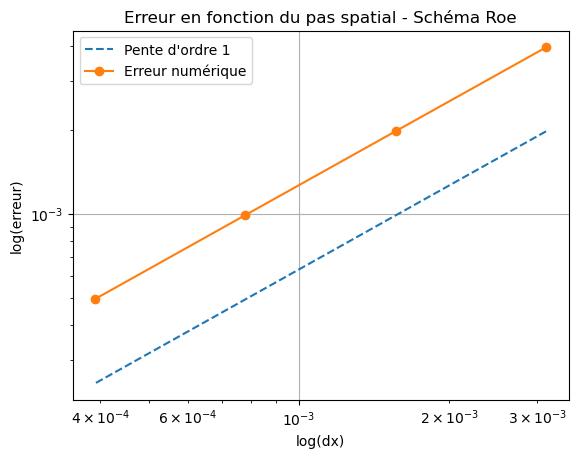

In [33]:
T= 1.
dt_init = 0.01
N_values = [3200, 6400, 12800, 25600]
vals_erreurLinf = []
vals_erreurL2 = []
dx_vals = []
for N in N_values:
    x = np.linspace(-5, 5, N)
    xm = (x[:-1]+x[1:])/2.
    dx = np.diff(x)
    u0 = u_exact(x, 0) #condition initiale
    u = burgers_roe_f(f,x, u0, T, dt_init)
    u_e = u_exact(xm, T)
    

    erreur = u - u_e
    vals_erreurLinf.append(np.max(np.abs(erreur)))
    vals_erreurL2.append(np.sqrt(np.sum(erreur**2)))
    dx_vals.append(np.mean(dx))


log_dx = np.log(dx_vals)
log_N= np.log(N_values)
log_erreurLinf = np.log(vals_erreurLinf)
log_erreurL2 = np.log(vals_erreurL2)
pente2, intercept2 = np.polyfit(log_dx, log_erreurLinf, 1)
pente3, intercept3 = np.polyfit(log_dx, log_erreurL2, 1)

print(f"Ordre de convergence Linf (Roe) estimé: {pente2:.2f}")
print(f"Ordre de convergence L2 (Roe) estimé: {pente3:.2f}")


# Ajout de la pente d'ordre 1
dx_ref = np.array(dx_vals)
erreur_ref = 0.5*vals_erreurLinf[0] * (dx_ref / dx_ref[0])  # Droite de référence avec pente 1
plt.loglog(dx_ref, erreur_ref, linestyle='--', label="Pente d'ordre 1")

plt.loglog(dx_vals, vals_erreurLinf, marker='o', label="Erreur numérique")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial - Schéma Roe')
plt.legend()
plt.grid()
plt.savefig("erreur roe burgers.png")    
plt.show()